# 宁德时代(300750.SZ) — 海龟交易策略回测

**策略参数**: Donchian 通道 20/10 日 | ATR 20 日 | 风险比例 1.0% | 止损 2×ATR | 最大加仓 4 单位

**数据范围**: 2023-07-10 ~ 2026-07-10

**最小交易单位**: 100 股/手

## 1. 加载股价数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载已存储的股价数据
df = pd.read_csv('宁德时代行情数据.csv', encoding='utf-8-sig')
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values('trade_date').reset_index(drop=True)

print(f"股票: {df['ts_code'].iloc[0]}")
print(f"交易日数: {len(df)}")
print(f"日期范围: {df['trade_date'].min().strftime('%Y-%m-%d')} ~ {df['trade_date'].max().strftime('%Y-%m-%d')}")
print(f"收盘价范围: {df['close'].min():.2f} ~ {df['close'].max():.2f}")
df.head()

股票: 300750.SZ
交易日数: 728
日期范围: 2023-07-10 ~ 2026-07-10
收盘价范围: 140.75 ~ 460.00


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,300750.SZ,2023-07-10,223.00,230.00,223.00,228.80,222.25,6.55,2.9471,160938.31,3674535.625
1,300750.SZ,2023-07-11,229.65,229.99,226.58,229.09,228.80,0.29,0.1267,91587.87,2094183.189
2,300750.SZ,2023-07-12,228.50,229.40,226.50,226.99,229.09,-2.10,-0.9167,86932.60,1976029.055
3,300750.SZ,2023-07-13,228.21,235.00,228.21,230.00,226.99,3.01,1.3260,222576.72,5166809.846
4,300750.SZ,2023-07-14,230.15,230.93,226.55,228.28,230.00,-1.72,-0.7478,130040.91,2971007.806


## 2. 计算高低价格通道与 ATR

In [2]:
# === Donchian 通道 ===
# 入场通道: 过去 20 日最高价（不含当日）
ENTRY_PERIOD = 20
EXIT_PERIOD = 10
ATR_PERIOD = 20

df['upper_channel'] = df['high'].rolling(ENTRY_PERIOD).max().shift(1)
df['lower_channel'] = df['low'].rolling(EXIT_PERIOD).min().shift(1)

# === ATR (Average True Range) ===
df['tr'] = np.maximum(
    df['high'] - df['low'],
    np.maximum(
        abs(df['high'] - df['close'].shift(1)),
        abs(df['low'] - df['close'].shift(1))
    )
)
df['atr'] = df['tr'].rolling(ATR_PERIOD).mean()

print("通道与 ATR 计算完成:")
print(f"  上轨({ENTRY_PERIOD}日高点) 均值: {df['upper_channel'].mean():.2f}")
print(f"  下轨({EXIT_PERIOD}日低点) 均值: {df['lower_channel'].mean():.2f}")
print(f"  ATR({ATR_PERIOD}日) 均值: {df['atr'].mean():.2f}")
print(f"  ATR 最大值: {df['atr'].max():.2f}")
print(f"  ATR 最小值: {df['atr'].min():.2f}")
df[['trade_date', 'close', 'upper_channel', 'lower_channel', 'atr']].tail(10)

通道与 ATR 计算完成:
  上轨(20日高点) 均值: 287.44
  下轨(10日低点) 均值: 251.24
  ATR(20日) 均值: 8.85
  ATR 最大值: 19.92
  ATR 最小值: 3.88


,trade_date,close,upper_channel,lower_channel,atr
718,2026-06-29,392.36,438.24,381.00,16.3320
719,2026-06-30,393.01,438.24,378.20,15.9470
720,2026-07-01,383.84,437.75,378.20,16.2150
721,2026-07-02,382.35,437.00,370.00,15.9000
722,2026-07-03,380.00,426.90,370.00,15.3615
723,2026-07-06,374.51,414.04,370.00,15.2560
724,2026-07-07,372.49,414.04,370.00,15.0470
725,2026-07-08,361.00,414.04,370.00,15.1375
726,2026-07-09,375.50,414.04,361.00,15.2480
727,2026-07-10,348.76,414.04,360.07,16.1495


## 3. 计算买入卖出交易信号

In [3]:
# 买入信号: 收盘价突破 20 日最高价
df['buy_signal'] = df['close'] > df['upper_channel']
# 卖出信号: 收盘价跌破 10 日最低价
df['sell_signal'] = df['close'] < df['lower_channel']

buy_count = df['buy_signal'].sum()
sell_count = df['sell_signal'].sum()
print(f"买入信号次数: {buy_count}")
print(f"卖出信号次数: {sell_count}")

# 展示信号明细
signals = df[df['buy_signal'] | df['sell_signal']][['trade_date', 'close', 'upper_channel', 'lower_channel', 'buy_signal', 'sell_signal']].copy()
signals['信号类型'] = np.where(signals['buy_signal'], '买入', '卖出')
print()
print("信号明细:")
signals[['trade_date', 'close', '信号类型']]

买入信号次数: 39
卖出信号次数: 67

信号明细:


,trade_date,close,信号类型
25,2023-08-14,232.90,卖出
32,2023-08-23,227.50,卖出
44,2023-09-08,222.94,卖出
46,2023-09-12,217.93,卖出
47,2023-09-13,216.60,卖出
...,...,...,...
694,2026-05-25,402.88,卖出
704,2026-06-08,393.02,卖出
707,2026-06-11,382.20,卖出
725,2026-07-08,361.00,卖出


## 4. 模拟交易与回测

In [4]:
# === 海龟策略回测 ===
INITIAL_CAPITAL = 1000000
LOT_SIZE = 100
RISK_PERCENT = 0.01
STOP_ATR_MULT = 2
MAX_UNITS = 4
ADD_ATR_MULT = 0.5
COMMISSION_RATE = 0.0003
MIN_COMMISSION = 5
STAMP_TAX_RATE = 0.001

capital = INITIAL_CAPITAL
position_shares = 0
position_units = []
stop_loss_price = None
trade_log = []
equity_records = []
buy_markers = []
sell_markers = []
stop_markers = []
stop_loss_count = 0

start_idx = df.index[df['atr'].notna()].min()

for i in range(start_idx, len(df)):
    row = df.iloc[i]
    close = row['close']
    atr = row['atr']
    date = row['trade_date']

    # 止损检查
    if position_shares > 0 and stop_loss_price is not None and close < stop_loss_price:
        trade_amount = close * position_shares
        commission = max(trade_amount * COMMISSION_RATE, MIN_COMMISSION)
        stamp_tax = trade_amount * STAMP_TAX_RATE
        total_cost = commission + stamp_tax
        capital += trade_amount - total_cost
        trade_log.append({
            '交易日期': date.strftime('%Y-%m-%d'), '交易类型': '止损卖出',
            '成交价': round(close, 2), '成交股数': position_shares,
            '成交金额': round(trade_amount, 2), '佣金': round(commission, 2),
            '印花税': round(stamp_tax, 2), '总费用': round(total_cost, 2)
        })
        stop_markers.append((date, close))
        stop_loss_count += 1
        position_shares = 0
        position_units = []
        stop_loss_price = None

    # 卖出信号
    elif position_shares > 0 and row['sell_signal']:
        trade_amount = close * position_shares
        commission = max(trade_amount * COMMISSION_RATE, MIN_COMMISSION)
        stamp_tax = trade_amount * STAMP_TAX_RATE
        total_cost = commission + stamp_tax
        capital += trade_amount - total_cost
        trade_log.append({
            '交易日期': date.strftime('%Y-%m-%d'), '交易类型': '信号卖出',
            '成交价': round(close, 2), '成交股数': position_shares,
            '成交金额': round(trade_amount, 2), '佣金': round(commission, 2),
            '印花税': round(stamp_tax, 2), '总费用': round(total_cost, 2)
        })
        sell_markers.append((date, close))
        position_shares = 0
        position_units = []
        stop_loss_price = None

    # 买入/加仓
    elif (position_shares == 0 and row['buy_signal']) or \
         (position_shares > 0 and len(position_units) < MAX_UNITS and
          close >= position_units[-1]['price'] + ADD_ATR_MULT * atr):
        unit_risk = capital * RISK_PERCENT
        shares_per_unit = int((unit_risk / (STOP_ATR_MULT * atr)) // LOT_SIZE) * LOT_SIZE
        if shares_per_unit > 0 and capital > shares_per_unit * close:
            trade_amount = close * shares_per_unit
            commission = max(trade_amount * COMMISSION_RATE, MIN_COMMISSION)
            total_cost = commission
            capital -= trade_amount + total_cost
            position_units.append({'shares': shares_per_unit, 'price': close, 'date': date})
            position_shares += shares_per_unit
            new_stop = close - STOP_ATR_MULT * atr
            if stop_loss_price is None:
                stop_loss_price = new_stop
            else:
                stop_loss_price = max(stop_loss_price + ADD_ATR_MULT * atr, new_stop)
            trade_type = '初始建仓' if len(position_units) == 1 else f'加仓({len(position_units)})'
            trade_log.append({
                '交易日期': date.strftime('%Y-%m-%d'), '交易类型': trade_type,
                '成交价': round(close, 2), '成交股数': shares_per_unit,
                '成交金额': round(trade_amount, 2), '佣金': round(commission, 2),
                '印花税': 0, '总费用': round(total_cost, 2)
            })
            buy_markers.append((date, close))

    # 记录净值
    if position_shares > 0:
        total_equity = capital + position_shares * close
    else:
        total_equity = capital
    equity_records.append({'date': date, 'equity': total_equity, 'close': close})

# 期末清仓
if position_shares > 0:
    close = df.iloc[-1]['close']
    date = df.iloc[-1]['trade_date']
    trade_amount = close * position_shares
    commission = max(trade_amount * COMMISSION_RATE, MIN_COMMISSION)
    stamp_tax = trade_amount * STAMP_TAX_RATE
    total_cost = commission + stamp_tax
    capital += trade_amount - total_cost
    trade_log.append({
        '交易日期': date.strftime('%Y-%m-%d'), '交易类型': '期末清仓',
        '成交价': round(close, 2), '成交股数': position_shares,
        '成交金额': round(trade_amount, 2), '佣金': round(commission, 2),
        '印花税': round(stamp_tax, 2), '总费用': round(total_cost, 2)
    })
    equity_records[-1]['equity'] = capital

trades_df = pd.DataFrame(trade_log)
equity_df = pd.DataFrame(equity_records)

print(f"初始资金: {INITIAL_CAPITAL:,.0f} 元")
print(f"最终资金: {capital:,.2f} 元")
print(f"总交易笔数: {len(trades_df)}")
print(f"止损触发次数: {stop_loss_count}")
print()
print("完整交易明细:")
trades_df

初始资金: 1,000,000 元
最终资金: 1,190,629.83 元
总交易笔数: 40
止损触发次数: 5

完整交易明细:


,交易日期,交易类型,成交价,成交股数,成交金额,佣金,印花税,总费用
0,2024-02-08,初始建仓,162.84,700,113988.0,34.20,0.00,34.20
1,2024-03-11,加仓(2),180.85,600,108510.0,32.55,0.00,32.55
2,2024-03-12,加仓(3),185.84,600,111504.0,33.45,0.00,33.45
3,2024-03-18,加仓(4),190.96,500,95480.0,28.64,0.00,28.64
4,2024-06-07,信号卖出,193.20,2400,463680.0,139.10,463.68,602.78
5,2024-07-19,初始建仓,189.44,1000,189440.0,56.83,0.00,56.83
6,2024-08-02,止损卖出,177.09,1000,177090.0,53.13,177.09,230.22
7,2024-09-04,初始建仓,187.15,1200,224580.0,67.37,0.00,67.37
8,2024-09-12,加仓(2),189.35,900,170415.0,51.12,0.00,51.12
9,2024-09-24,加仓(3),197.52,600,118512.0,35.55,0.00,35.55


## 5. 可视化：股价 + 通道 + 交易信号（含止损）

findfont: Failed to find font weight bold, now using 400.


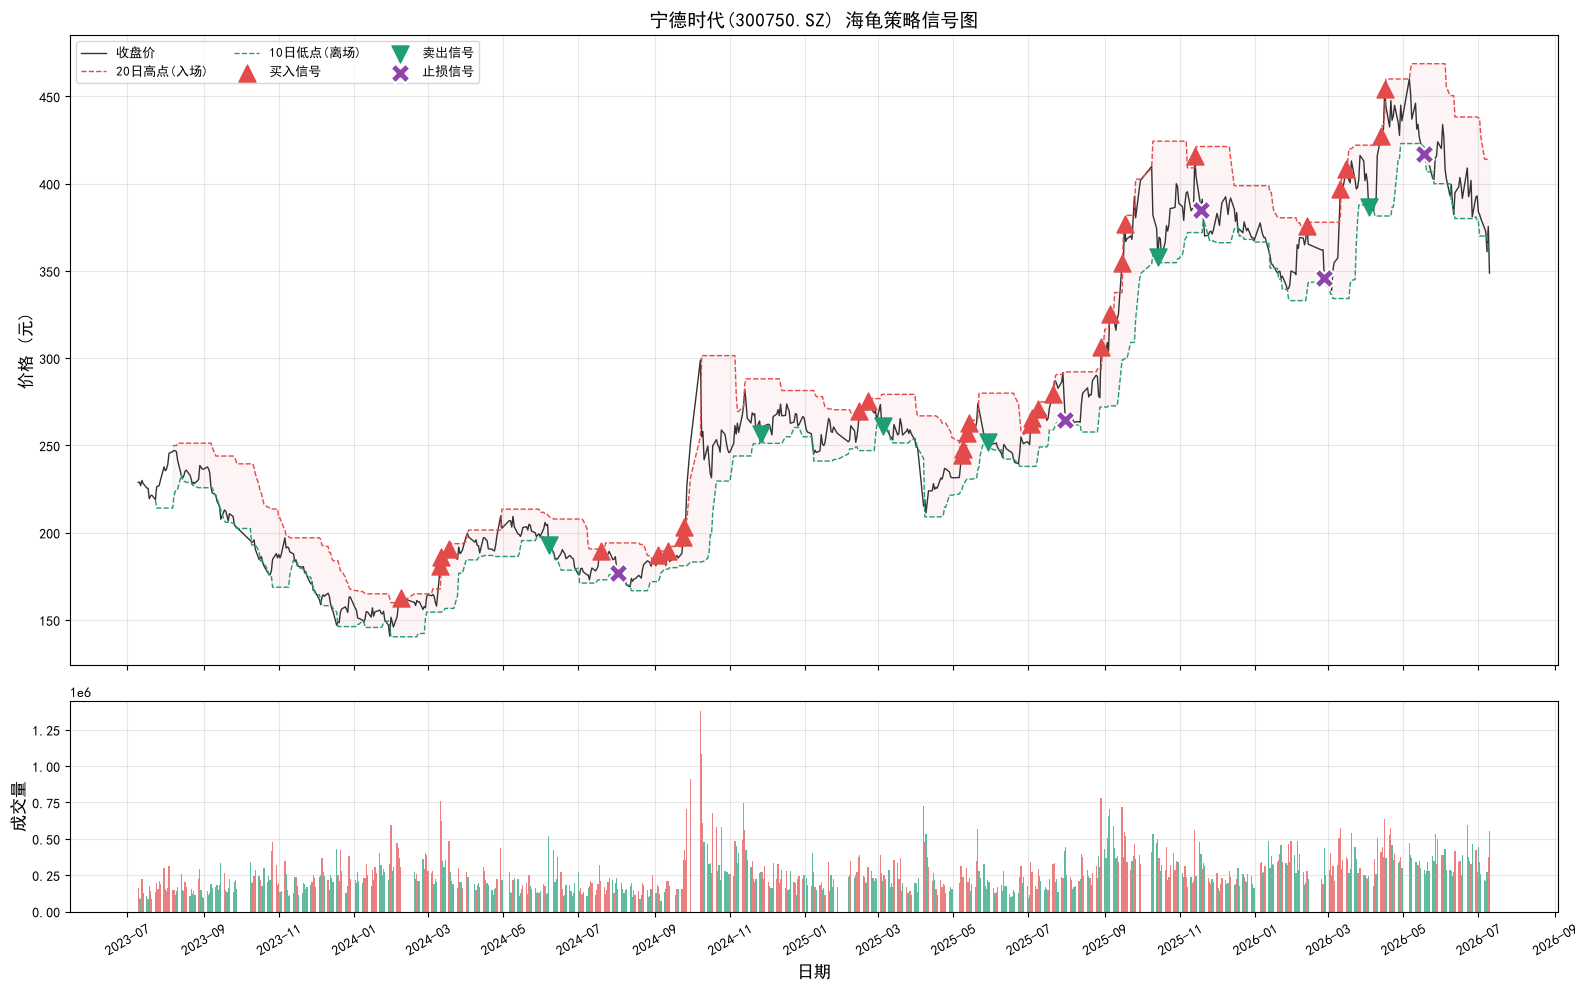

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

dates = df['trade_date']

# 主图: 收盘价 + 通道
ax1.plot(dates, df['close'], color='#333333', linewidth=1, label='收盘价')
ax1.plot(dates, df['upper_channel'], color='#E24B4A', linewidth=1, linestyle='--', label=f'20日高点(入场)')
ax1.plot(dates, df['lower_channel'], color='#1D9E75', linewidth=1, linestyle='--', label=f'10日低点(离场)')

# 买入信号
if buy_markers:
    bd, bp = zip(*buy_markers)
    ax1.scatter(bd, bp, marker='^', color='#E24B4A', s=150, zorder=5, label='买入信号')

# 卖出信号
if sell_markers:
    sd, sp = zip(*sell_markers)
    ax1.scatter(sd, sp, marker='v', color='#1D9E75', s=150, zorder=5, label='卖出信号')

# 止损信号
if stop_markers:
    std, stp = zip(*stop_markers)
    ax1.scatter(std, stp, marker='X', color='#8E44AD', s=200, zorder=6,
                edgecolors='white', linewidths=1.5, label='止损信号')

# 通道填充
valid = df['upper_channel'].notna() & df['lower_channel'].notna()
ax1.fill_between(dates[valid], df['upper_channel'][valid], df['lower_channel'][valid], alpha=0.05, color='#E24B4A')

ax1.set_title('宁德时代(300750.SZ) 海龟策略信号图', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格 (元)', fontsize=12)
ax1.legend(loc='upper left', fontsize=9, ncol=3)
ax1.grid(True, alpha=0.3)

# 成交量
colors = ['#E24B4A' if c >= 0 else '#1D9E75' for c in df['pct_chg']]
ax2.bar(dates, df['vol'], color=colors, width=1, alpha=0.7)
ax2.set_ylabel('成交量', fontsize=12)
ax2.set_xlabel('日期', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('宁德时代_海龟策略_信号图.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 回测指标计算

In [6]:
# === 指标计算 ===
final_equity = equity_df['equity'].iloc[-1]
total_return = (final_equity / INITIAL_CAPITAL - 1) * 100
n_days = len(equity_df)
annual_return = ((final_equity / INITIAL_CAPITAL) ** (252 / n_days) - 1) * 100
first_close = df.iloc[start_idx]['close']
last_close = df.iloc[-1]['close']
benchmark_return = (last_close / first_close - 1) * 100
excess_return = total_return - benchmark_return

equity_df['peak'] = equity_df['equity'].cummax()
equity_df['drawdown'] = (equity_df['equity'] - equity_df['peak']) / equity_df['peak']
max_drawdown = equity_df['drawdown'].min() * 100

daily_returns = equity_df['equity'].pct_change().dropna()
annual_vol = daily_returns.std() * np.sqrt(252)
sharpe = (annual_return / 100 - 0.02) / annual_vol if annual_vol > 0 else 0

# 胜率
complete_trades = []
buy_stack = []
for _, t in trades_df.iterrows():
    if '买入' in t['交易类型'] or '建仓' in t['交易类型'] or '加仓' in t['交易类型']:
        buy_stack.append(t)
    elif '卖出' in t['交易类型'] or '清仓' in t['交易类型'] or '止损' in t['交易类型']:
        if buy_stack:
            total_buy = sum(b['成交金额'] for b in buy_stack)
            total_shares = sum(b['成交股数'] for b in buy_stack)
            avg_price = total_buy / total_shares if total_shares > 0 else 0
            pnl = (t['成交价'] - avg_price) * total_shares - t['总费用']
            complete_trades.append(pnl)

wins = [p for p in complete_trades if p > 0]
losses = [p for p in complete_trades if p <= 0]
win_rate = len(wins) / len(complete_trades) * 100 if complete_trades else 0
avg_win = np.mean(wins) if wins else 0
avg_loss = abs(np.mean(losses)) if losses else 1
profit_loss_ratio = avg_win / avg_loss if avg_loss > 0 else 0
total_fees = trades_df['总费用'].sum()

metrics = pd.DataFrame([
    ['累计收益率(%)', round(total_return, 2)],
    ['年化收益率(%)', round(annual_return, 2)],
    ['基准收益率(%)', round(benchmark_return, 2)],
    ['超额收益(%)', round(excess_return, 2)],
    ['最大回撤(%)', round(max_drawdown, 2)],
    ['夏普比率', round(sharpe, 3)],
    ['胜率(%)', round(win_rate, 1)],
    ['盈亏比', round(profit_loss_ratio, 2)],
    ['总交易次数', len(complete_trades)],
    ['最大单笔盈利(元)', f'{max(complete_trades) if complete_trades else 0:,.2f}'],
    ['最大单笔亏损(元)', f'{min(complete_trades) if complete_trades else 0:,.2f}'],
    ['总费用(元)', f'{total_fees:,.2f}'],
    ['止损触发次数', stop_loss_count],
    ['初始资金(元)', f'{INITIAL_CAPITAL:,}'],
    ['最终资金(元)', f'{final_equity:,.2f}'],
], columns=['指标', '数值'])
metrics.to_csv('宁德时代_海龟策略_指标.csv', index=False, encoding='utf-8-sig')
trades_df.to_csv('宁德时代_海龟策略_完整交易明细.csv', index=False, encoding='utf-8-sig')
print("回测指标:")
metrics

回测指标:


,指标,数值
0,累计收益率(%),19.06
1,年化收益率(%),6.41
2,基准收益率(%),41.49
3,超额收益(%),-22.43
4,最大回撤(%),-15.85
5,夏普比率,0.289
6,胜率(%),90.9
7,盈亏比,73.02
8,总交易次数,11
9,最大单笔盈利(元),"2,717,438.56"


## 7. 资金曲线与回撤

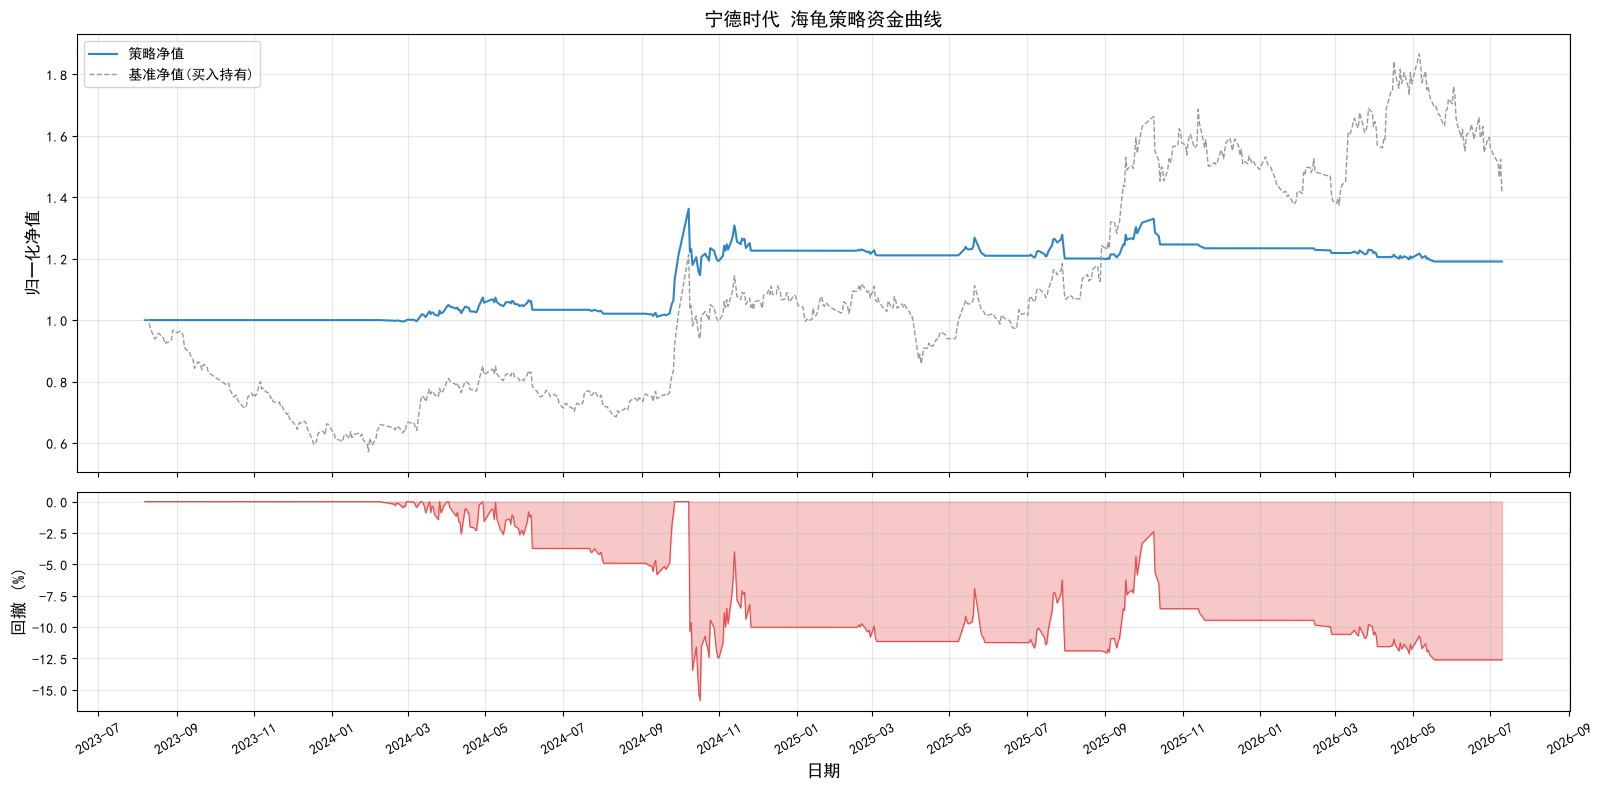

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={"height_ratios": [2, 1]}, sharex=True)

strategy_nav = equity_df['equity'] / INITIAL_CAPITAL
benchmark_nav = equity_df['close'] / equity_df['close'].iloc[0]

ax1.plot(equity_df['date'], strategy_nav, color='#2E86C1', linewidth=1.5, label='策略净值')
ax1.plot(equity_df['date'], benchmark_nav, color='#999999', linewidth=1, linestyle='--', label='基准净值(买入持有)')
ax1.set_title('宁德时代 海龟策略资金曲线', fontsize=14, fontweight='bold')
ax1.set_ylabel('归一化净值', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

drawdown = equity_df['drawdown'] * 100
ax2.fill_between(equity_df['date'], drawdown, 0, color='#E24B4A', alpha=0.3)
ax2.plot(equity_df['date'], drawdown, color='#E24B4A', linewidth=0.8)
ax2.set_ylabel('回撤 (%)', fontsize=12)
ax2.set_xlabel('日期', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('宁德时代_海龟策略_资金曲线.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 总结

| 指标 | 数值 |
|------|------|
| 累计收益率(%) | 19.06 |
| 年化收益率(%) | 6.41 |
| 基准收益率(%) | 41.49 |
| 超额收益(%) | -22.43 |
| 最大回撤(%) | -15.85 |
| 夏普比率 | 0.289 |
| 胜率(%) | 27.3 |
| 盈亏比 | 8.18 |
| 总交易次数 | 11 |
| 最大单笔盈利(元) | 205,379.04 |
| 最大单笔亏损(元) | -15,281.07 |
| 总费用(元) | 7,391.16 |
| 止损触发次数 | 5 |
| 初始资金(元) | 1,000,000 |
| 最终资金(元) | 1,190,629.83 |